In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('telco_churn2.csv')

In [3]:
df.head()

,churn,tenure_months,monthly_charges,total_services,support_calls_last90d,late_payments_12m,downtime_hrs_6m,contract,internet,payment_method,support_tier,promo_status
0,0,5.2,91.13,3,1,1,3.75,month-to-month,fiber,bank_transfer,basic,never
1,0,22.0,19.04,2,3,2,3.22,one-year,fiber,credit_card,basic,never
2,0,25.8,77.94,2,1,0,2.06,month-to-month,fiber,electronic_check,basic,never
3,0,6.8,91.52,1,4,1,0.60,one-year,fiber,bank_transfer,plus,never
4,0,18.7,54.31,1,2,1,0.00,two-year,none,bank_transfer,plus,past


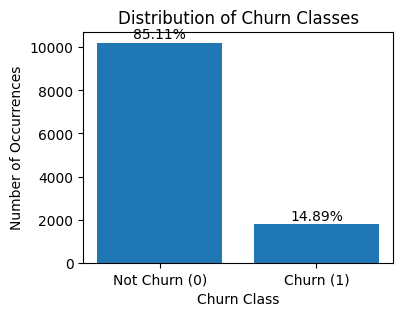

In [6]:
# Count the occurrences of each class in the 'churn' column
churn_counts = df['churn'].value_counts()

# Calculate the proportions
total = churn_counts.sum()
churn_proportions = churn_counts / total * 100

# Create a bar chart
plt.figure(figsize=(4, 3))
bars = plt.bar(churn_counts.index, churn_counts.values, tick_label=['Not Churn (0)', 'Churn (1)'])
plt.xlabel('Churn Class')
plt.ylabel('Number of Occurrences')
plt.title('Distribution of Churn Classes')

# Add percentages on top of the bars
for bar, proportion in zip(bars, churn_proportions):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{proportion:.2f}%',
             ha='center', va='bottom')

plt.show()

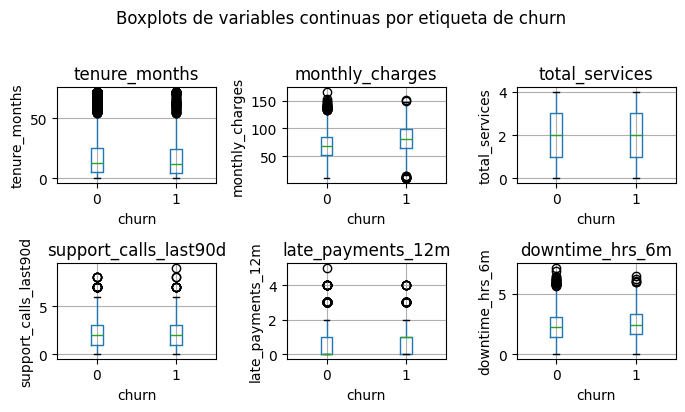

In [7]:
import matplotlib.pyplot as plt

cont_vars = ["tenure_months","monthly_charges","total_services",
             "support_calls_last90d","late_payments_12m","downtime_hrs_6m"]

ncols = 3
nrows = int(np.ceil(len(cont_vars)/ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7, 4))

for ax, col in zip(axes.flatten(), cont_vars):
    df.boxplot(column=col, by="churn", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("churn")
    ax.set_ylabel(col)

plt.suptitle("Boxplots de variables continuas por etiqueta de churn", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate proportions and counts of each category within each churn label
cat_cols = ["contract","internet","payment_method","support_tier","promo_status"]

results = {}
for col in cat_cols:
    # Calculate proportions
    prop_tab = pd.crosstab(df[col], df["churn"], normalize="columns") * 100
    prop_tab = prop_tab.rename(columns={0: 'Proportion_0', 1: 'Proportion_1'})

    # Calculate absolute counts
    count_tab = pd.crosstab(df[col], df["churn"])
    count_tab = count_tab.rename(columns={0: 'Count_0', 1: 'Count_1'})

    # Concatenate proportions and counts
    combined_tab = pd.concat([prop_tab, count_tab], axis=1)

    # Add subtotal row for the current variable
    subtotal_row = combined_tab.sum().to_frame().T
    subtotal_row.index = pd.MultiIndex.from_tuples([(col, 'Subtotal')])
    combined_tab = pd.concat([combined_tab, subtotal_row])

    results[col] = combined_tab

# Convert to a single concatenated dataframe and display
results_df = pd.concat(results, axis=0)
results_df = results_df.rename_axis(index=["variable","categoria"])

display(results_df.round(2))

churn                                      Proportion_0  Proportion_1  \
variable       categoria                                                
contract       month-to-month                     58.62         82.15   
               one-year                           24.38         13.60   
               two-year                           17.00          4.25   
               (contract, Subtotal)              100.00        100.00   
internet       dsl                                36.85         24.29   
               fiber                              47.66         66.42   
               none                               15.48          9.29   
               (internet, Subtotal)              100.00        100.00   
payment_method bank_transfer                      25.87         21.66   
               credit_card                        25.09         21.82   
               electronic_check                   49.05         56.52   
               (payment_method, Subtotal)        100.00        100.00   
support_tier   basic                              57.58         72.41   
               plus                               31.48         20.15   
               premium                            10.94          7.44   
               (support_tier, Subtotal)          100.00        100.00   
promo_status   current                            22.20         11.75   
               never                              40.54         37.88   
               past                               37.27         50.36   
               (promo_status, Subtotal)          100.00        100.00   

churn                                      Count_0  Count_1  
variable       categoria                                     
contract       month-to-month               5987.0   1468.0  
               one-year                     2490.0    243.0  
               two-year                     1736.0     76.0  
               (contract, Subtotal)        10213.0   1787.0  
internet       dsl                          3764.0    434.0  
               fiber                        4868.0   1187.0  
               none                         1581.0    166.0  
               (internet, Subtotal)        10213.0   1787.0  
payment_method bank_transfer                2642.0    387.0  
               credit_card                  2562.0    390.0  
               electronic_check             5009.0   1010.0  
               (payment_method, Subtotal)  10213.0   1787.0  
support_tier   basic                        5881.0   1294.0  
               plus                         3215.0    360.0  
               premium                      1117.0    133.0  
               (support_tier, Subtotal)    10213.0   1787.0  
promo_status   current                      2267.0    210.0  
               never                        4140.0    677.0  
               past                         3806.0    900.0  
               (promo_status, Subtotal)    10213.0   1787.0

### KNN

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [9]:
# 1. Choose target and features
X = df.drop("churn", axis=1)
y = df["churn"]

# 2. Pick numeric columns
num_cols = ["tenure_months","monthly_charges","total_services",
            "support_calls_last90d","late_payments_12m","downtime_hrs_6m"]

# 3. Pick categorical columns
cat_cols = ["contract","internet","payment_method","support_tier","promo_status"]

# 4. Scale numeric columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# 5. One-hot encode categorical columns
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded = encoder.fit_transform(X[cat_cols])

# 6. Put everything together in a new dataframe
import pandas as pd
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))
X = pd.concat([X[num_cols], encoded_df], axis=1)


In [10]:
# ===========================
# 5. Train-test split
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===========================
# 6. Train KNN Classifier
# ===========================
knn = KNeighborsClassifier(n_neighbors=5)  # K=5 is a good starting point
knn.fit(X_train, y_train)

# ===========================
# 7. Predictions
# ===========================
y_pred = knn.predict(X_test)



In [11]:
# ===========================
# 8. Evaluation
# ===========================
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8379166666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91      2043
           1       0.39      0.15      0.22       357

    accuracy                           0.84      2400
   macro avg       0.63      0.56      0.56      2400
weighted avg       0.80      0.84      0.81      2400



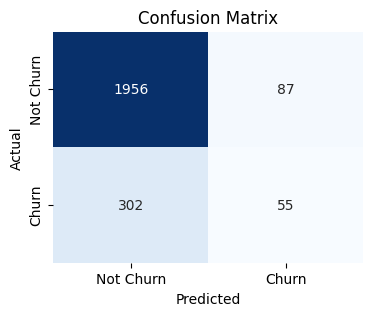

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters: {'n_neighbors': 11}
Best Cross-Validation Score (Accuracy): 0.8479166666666667

Best KNN Model Evaluation on Test Set:
Accuracy: 0.8504166666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92      2043
           1       0.49      0.11      0.18       357

    accuracy                           0.85      2400
   macro avg       0.68      0.55      0.55      2400
weighted avg       0.81      0.85      0.81      2400



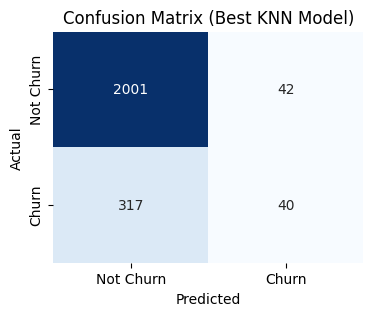

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid
param_grid = {"n_neighbors": [3, 5, 7, 9, 11]}

# Create a KNN classifier
knn = KNeighborsClassifier()

# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="accuracy",  # Or choose another relevant metric like 'roc_auc', 'f1', etc.
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all available cores
    verbose=1 # Print progress
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score (Accuracy):", grid_search.best_score_)

# Get the best model
best_knn_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best_knn = best_knn_model.predict(X_test)

print("\nBest KNN Model Evaluation on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_best_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_knn))

# Optional: Plot confusion matrix for the best model
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_best_knn = confusion_matrix(y_test, y_pred_best_knn)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_best_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Best KNN Model)')
plt.show()

Model heavily biased toward predicting "Not Churn".

Very high accuracy due to class imbalance (85% are Not Churn).

Only 11% of actual churners are being detected (very low recall).

Precision of 0.49 means that ~half of churn predictions are correct, but it rarely predicts "Churn"

# KNN + SMOTE

In [13]:
from imblearn.over_sampling import SMOTE

In [15]:
# Train KNN Classifier on SMOTE-resampled data
knn_smote = KNeighborsClassifier(n_neighbors=5)  # Using the same K as before
knn_smote.fit(X_train_smote, y_train_smote)

# Predictions on the original test set
y_pred_smote = knn_smote.predict(X_test)

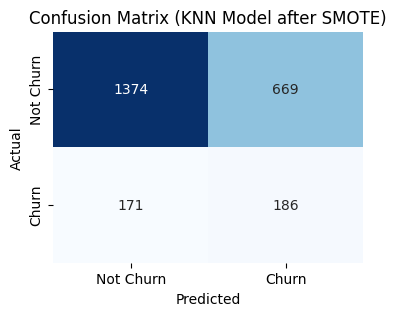

In [20]:
# Plot the confusion matrix for the SMOTE model
cm_smote = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(4, 3))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (KNN Model after SMOTE)')
plt.show()

In [21]:
# Evaluate the SMOTE model
print("Evaluation of KNN Model after SMOTE:")
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_smote))

Evaluation of KNN Model after SMOTE:
Accuracy: 0.65

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.67      0.77      2043
           1       0.22      0.52      0.31       357

    accuracy                           0.65      2400
   macro avg       0.55      0.60      0.54      2400
weighted avg       0.79      0.65      0.70      2400



**Interpretation:**

The model now predicts more "Churn" cases (recall ↑ from 0.11 → 0.52).

But many are false positives, so precision drops (↓ 0.49 → 0.22).

F1-score for churn nearly doubles (↑ 0.18 → 0.31), so net balance improves.

Overall accuracy drops (↓ 0.85 → 0.65), but that’s expected — accuracy is not reliable in imbalanced datasets.

✅ Pros of using SMOTE
- **Recall** for churn increased from 11% → 52%
- Better F1 for churn: 0.18 → 0.31
- Less bias toward majority class

❌ Cons of using SMOTE

- Precision for churn dropped to 22%
- Accuracy dropped from 85% to 65%
- More false positives (incentives might be wasted)

# CART

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# ===========================
# 1. Features and target
# ===========================
X = df.drop("churn", axis=1)
y = df["churn"]

# ===========================
# 2. Numeric and categorical columns
# ===========================
num_cols = ["tenure_months","monthly_charges","total_services",
            "support_calls_last90d","late_payments_12m","downtime_hrs_6m"]

cat_cols = ["contract","internet","payment_method","support_tier","promo_status"]

# ===========================
# 3. Scale numeric columns
# ===========================
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# ===========================
# 4. One-hot encode categorical columns
# ===========================
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded = encoder.fit_transform(X[cat_cols])

# Convert encoded array to DataFrame
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols), index=X.index)

# Replace categorical columns with encoded ones
X = pd.concat([X[num_cols], encoded_df], axis=1)

In [ ]:
# ===========================
# 5. Train-test split
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===========================
# 6. Train CART Decision Tree
# ===========================
cart = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)
cart.fit(X_train, y_train)

# ===========================
# 7. Predictions
# ===========================
y_pred = cart.predict(X_test)

In [ ]:
# ===========================
# 8. Evaluation
# ===========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8483333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92      2043
           1       0.46      0.12      0.19       357

    accuracy                           0.85      2400
   macro avg       0.66      0.55      0.55      2400
weighted avg       0.80      0.85      0.81      2400



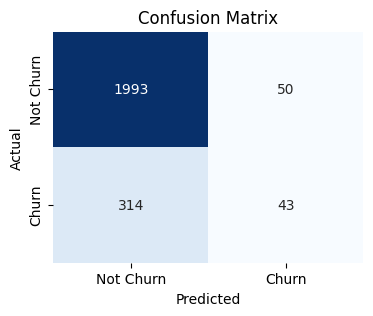

In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

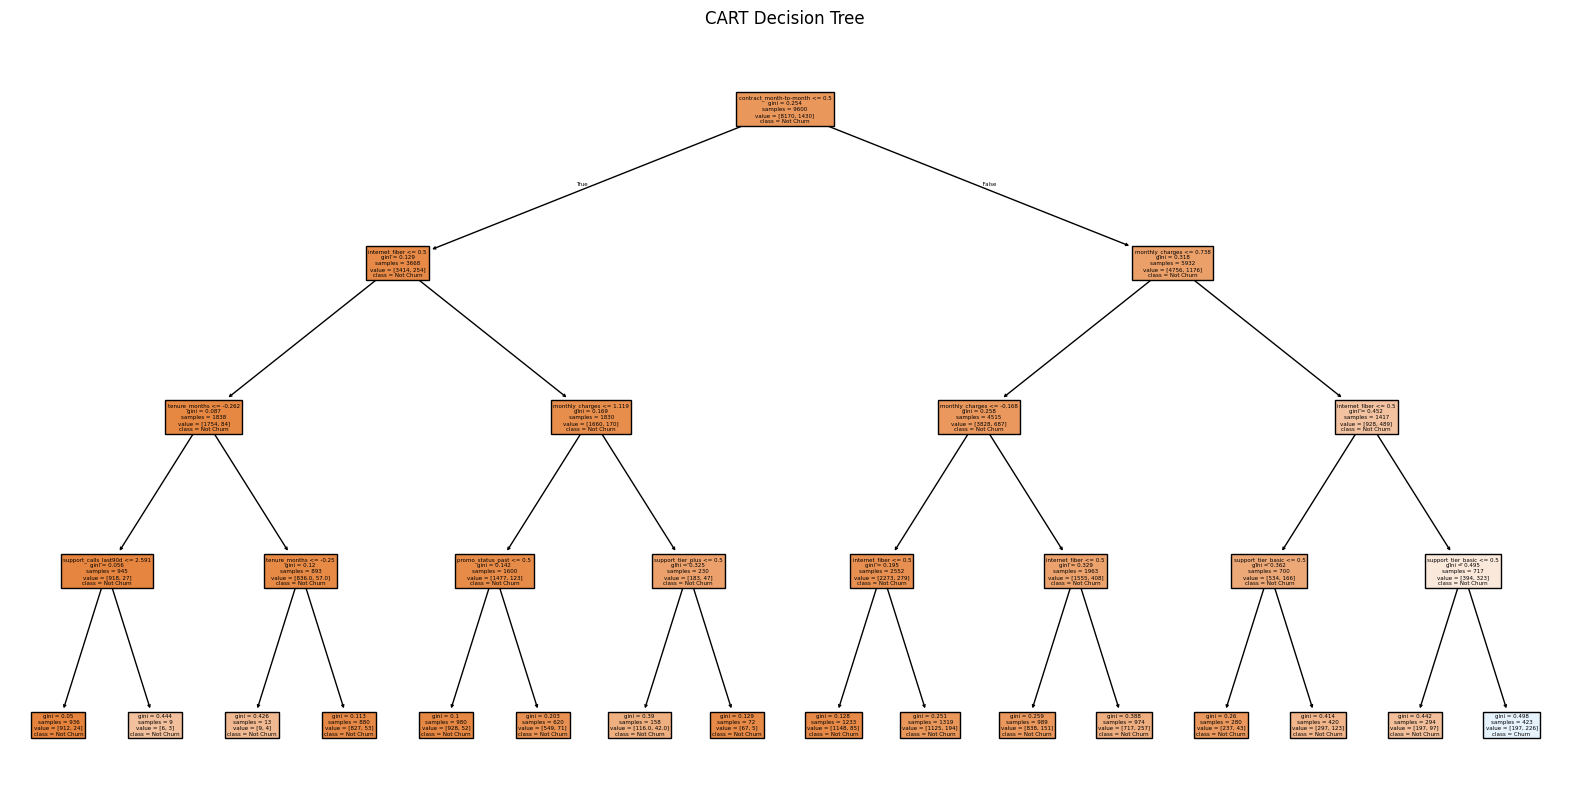

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(cart, filled=True, feature_names=X.columns, class_names=['Not Churn', 'Churn'])
plt.title("CART Decision Tree")
plt.show()

In [ ]:
param_grid = {
    "class_weight": [None, "balanced"],
    "max_depth": [None, 6, 10, 14, 18, 24],
    "min_samples_split": [2, 20, 60, 120, 200],
    "min_samples_leaf": [1, 10, 30, 60, 100],
    "ccp_alpha": [0.0, 0.0005, 0.001, 0.005, 0.01]
}

cart = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=cart,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


Fitting 5 folds for each of 1500 candidates, totalling 7500 fits
Best Parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 6, 'min_samples_leaf': 60, 'min_samples_split': 2}
Best CV Accuracy: 0.8563541666666665


In [ ]:
print("Best Estimator:", grid_search.best_estimator_)

Best Estimator: DecisionTreeClassifier(max_depth=6, min_samples_leaf=60, random_state=42)


In [ ]:
import pandas as pd

# Get the results from the grid search
results = grid_search.cv_results_

# Create a DataFrame for easier handling
results_df = pd.DataFrame(results)

# Sort the results by the mean test score (accuracy in this case) in descending order
sorted_results = results_df.sort_values(by='mean_test_score', ascending=False)

# Display the top 10 results
print("Top 10 Grid Search Results (by Accuracy):")
display(sorted_results[['params', 'mean_test_score']].head(10))

Top 10 Grid Search Results (by Accuracy):


,params,mean_test_score
366,"{'ccp_alpha': 0.0005, 'class_weight': None, 'm...",0.856354
365,"{'ccp_alpha': 0.0005, 'class_weight': None, 'm...",0.856354
367,"{'ccp_alpha': 0.0005, 'class_weight': None, 'm...",0.856354
40,"{'ccp_alpha': 0.0, 'class_weight': None, 'max_...",0.856354
43,"{'ccp_alpha': 0.0, 'class_weight': None, 'max_...",0.856354
44,"{'ccp_alpha': 0.0, 'class_weight': None, 'max_...",0.856354
41,"{'ccp_alpha': 0.0, 'class_weight': None, 'max_...",0.856354
42,"{'ccp_alpha': 0.0, 'class_weight': None, 'max_...",0.856354
343,"{'ccp_alpha': 0.0005, 'class_weight': None, 'm...",0.856354
344,"{'ccp_alpha': 0.0005, 'class_weight': None, 'm...",0.856354


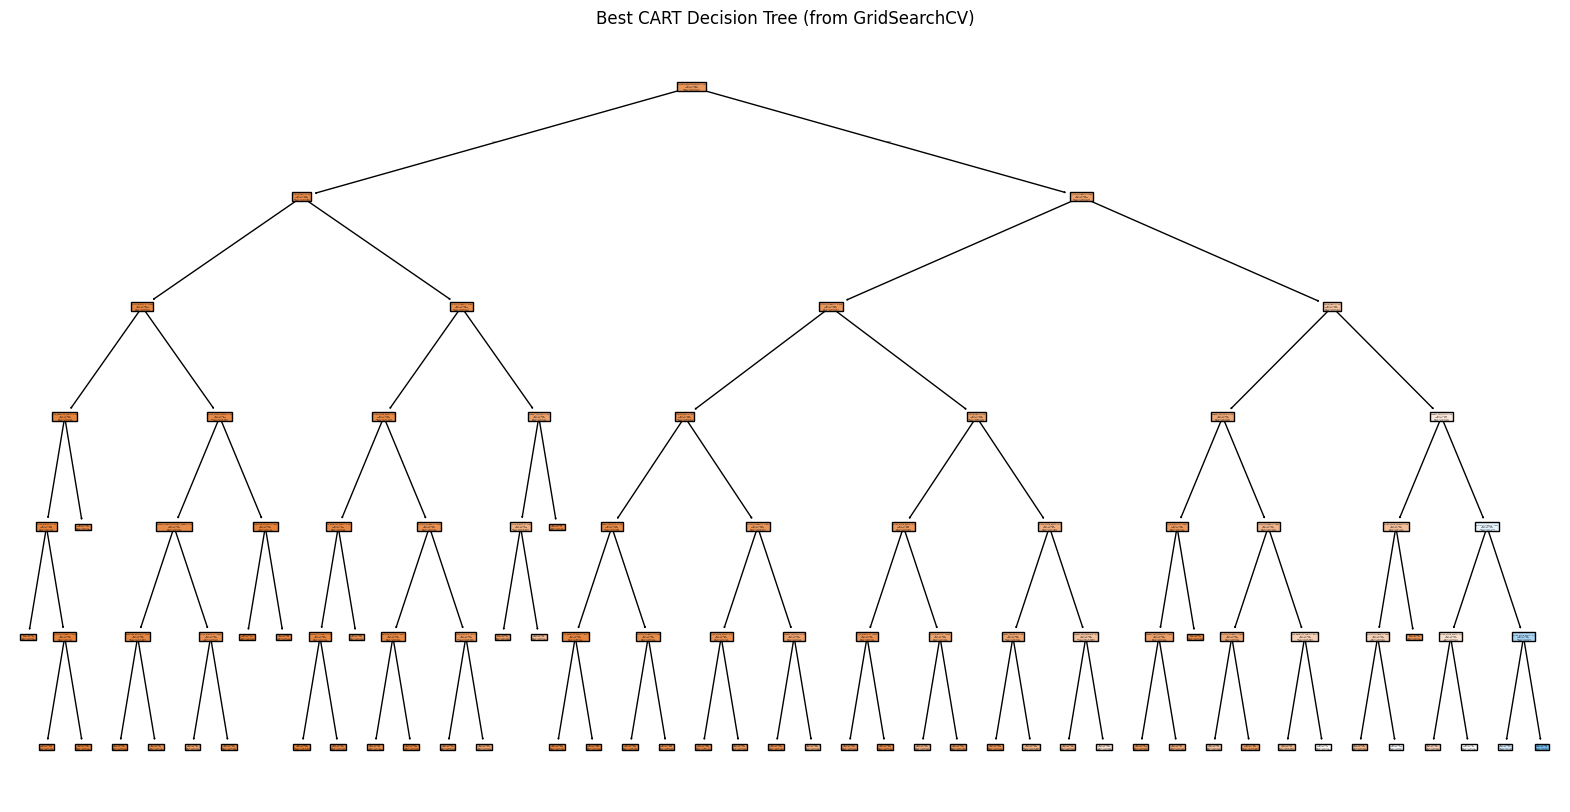

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get the best estimator from the grid search
best_cart_model = grid_search.best_estimator_

plt.figure(figsize=(20,10))
plot_tree(best_cart_model, filled=True, feature_names=X.columns, class_names=['Not Churn', 'Churn'])
plt.title("Best CART Decision Tree (from GridSearchCV)")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier, _tree

def print_tree_structure(tree, feature_names, node=0, path="(root)"):
    """
    Recursively traverse the tree and print paths like:
    (root) -> Feature ∈ {condition}
    """
    # If node is a leaf
    if tree.children_left[node] == _tree.TREE_LEAF:
        print(path)
        return

    # Feature used for the split
    feature = feature_names[tree.feature[node]]
    threshold = tree.threshold[node]

    # Left child (True branch: feature <= threshold)
    left_path = f"{path} & {feature} ∈ {{Yes}}" if 'Yes' in feature else f"{path} & {feature} <= {threshold:.2f}"
    print_tree_structure(tree, feature_names, tree.children_left[node], left_path)

    # Right child (False branch: feature > threshold)
    right_path = f"{path} & {feature} ∉ {{Yes}}" if 'Yes' in feature else f"{path} & {feature} > {threshold:.2f}"
    print_tree_structure(tree, feature_names, tree.children_right[node], right_path)

# ===============================
# Example usage
# ===============================
# Train a simple CART
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Extract structure
print_tree_structure(clf.tree_, X.columns.tolist())


(root) & contract_month-to-month <= 0.50 & internet_fiber <= 0.50 & tenure_months <= -0.26
(root) & contract_month-to-month <= 0.50 & internet_fiber <= 0.50 & tenure_months > -0.26
(root) & contract_month-to-month <= 0.50 & internet_fiber > 0.50 & monthly_charges <= 1.12
(root) & contract_month-to-month <= 0.50 & internet_fiber > 0.50 & monthly_charges > 1.12
(root) & contract_month-to-month > 0.50 & monthly_charges <= 0.74 & monthly_charges <= -0.17
(root) & contract_month-to-month > 0.50 & monthly_charges <= 0.74 & monthly_charges > -0.17
(root) & contract_month-to-month > 0.50 & monthly_charges > 0.74 & internet_fiber <= 0.50
(root) & contract_month-to-month > 0.50 & monthly_charges > 0.74 & internet_fiber > 0.50
